In [1]:
!nvidia-smi

Thu Mar  5 16:50:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch


def swa_naive(q, k, v, window_sizes: tuple[int, int] = (15, 16)):
    """
    Naive implementation of sliding window attention.

    Parameters
    ----------
    q : (..., L, Dqk) torch.Tensor
        Queries to compute attention with.
    k : (..., L, Dqk) torch.Tensor
        Keys to compute attention with.
    v : (..., L, Dv) torch.Tensor
        Values to compute attention with.
    window_sizes : tuple[int, int]
        The number of time-steps to look back- and forward, in that order.
        Causal masking is enabled when the second value is zero.

    Returns
    -------
    h : (..., L, Dv) torch.Tensor
        The computed output sequence.
    """
    bwd_win_size, fwd_win_size = window_sizes

    row_idx = torch.arange(q.shape[-2], device=q.device).unsqueeze(-1)
    col_idx = torch.arange(k.shape[-2], device=k.device).unsqueeze(-2)
    fwd_inv_mask = row_idx < col_idx - fwd_win_size
    bwd_inv_mask = row_idx > col_idx + bwd_win_size

    qk = q @ k.transpose(-1, -2)
    qk_masked = torch.masked_fill(qk, fwd_inv_mask | bwd_inv_mask, -float("inf"))
    a = torch.softmax(qk_masked, dim=-1)
    return a @ v


def swa_strided(q, k, v, window_sizes: tuple[int, int] = (15, 16)):
    """
    Sliding window attention implemented using striding tricks.
    """
    bwd_win_size, fwd_win_size = window_sizes
    win_size = 1 + bwd_win_size + fwd_win_size
    assert win_size < k.shape[-2]

    k_to_pad = [k.ravel()]
    v_to_pad = [v.ravel()]
    if bwd_win_size > 0:
        k_to_pad.insert(0, torch.zeros(bwd_win_size * k.shape[-1], device=k.device, dtype=k.dtype))
        v_to_pad.insert(0, torch.zeros(bwd_win_size * v.shape[-1], device=v.device, dtype=v.dtype))
    if fwd_win_size > 0:
        k_to_pad.append(torch.zeros(fwd_win_size * k.shape[-1], device=k.device, dtype=k.dtype))
        v_to_pad.append(torch.zeros(fwd_win_size * v.shape[-1], device=v.device, dtype=v.dtype))

    k_strided = torch.as_strided(
        torch.cat(k_to_pad, dim=0),
        size=(*k.shape[:-1], win_size, k.shape[-1]),
        stride=(*k.stride()[:-1], k.stride(-2), k.stride(-1))
    )
    v_strided = torch.as_strided(
        torch.cat(v_to_pad, dim=0),
        size=(*v.shape[:-1], win_size, v.shape[-1]),
        stride=(*v.stride()[:-1], v.stride(-2), v.stride(-1))
    )

    row_idx = torch.arange(q.shape[-2], device=q.device).unsqueeze(-1)
    col_idx = torch.arange(-bwd_win_size, fwd_win_size + 1, device=q.device).unsqueeze(-2)
    fwd_inv_mask = row_idx < -col_idx
    bwd_inv_mask = q.shape[-2] - 1 - row_idx < col_idx

    qk = torch.sum(q.unsqueeze(-2) * k_strided, dim=-1)
    qk_masked = torch.masked_fill(qk, fwd_inv_mask | bwd_inv_mask, -float("inf"))
    a = torch.softmax(qk_masked, dim=-1)
    return torch.sum(a.unsqueeze(-1) * v_strided, dim=-2)

In [5]:
batch_size = 2
num_heads = 8
seq_len = 128
d_qk = 64
d_v = 64

device = 'cuda' if torch.cuda.is_available() else 'cpu'

q = torch.randn(batch_size, num_heads, seq_len, d_qk, device=device, dtype=torch.float32)
k = torch.randn(batch_size, num_heads, seq_len, d_qk, device=device, dtype=torch.float32)
v = torch.randn(batch_size, num_heads, seq_len, d_v, device=device, dtype=torch.float32)

window_sizes = (15, 16)

output_naive = swa_naive(q, k, v, window_sizes=window_sizes)
output_strided = swa_strided(q, k, v, window_sizes=window_sizes)

is_close = torch.allclose(output_naive, output_strided, atol=1e-3, rtol=1e-3)

print(f"Is close: {is_close}")

print(f"Input shape: {q.shape}")
print(f"Output shape: {output_naive.shape}")
print(f"Output sample:\n{output_naive[0, 0, :5, :5]}")

Is close: True
Input shape: torch.Size([2, 8, 128, 64])
Output shape: torch.Size([2, 8, 128, 64])
Output sample:
tensor([[-0.2921, -0.6175,  0.1253, -0.7707,  0.4012],
        [-0.6685,  0.3642,  0.0317, -0.4733,  0.8106],
        [-1.6669,  0.2325, -0.1298,  1.3682, -0.0125],
        [-0.5449, -0.2100, -0.0771,  0.1203,  1.1604],
        [-0.7363,  1.0716, -1.0473, -0.1455, -0.0132]], device='cuda:0')


In [ ]:
is_close = torch.allclose(out_pt, out_tr, atol=1e-3, rtol=1e-3)

### Visualize Sliding Windows Attention

In [6]:
import numpy as np
import matplotlib.pyplot as plt


def visualize_sliding_attention(L=20, bwd_win=3, fwd_win=2):
    mask = np.zeros((L, L))

    for i in range(L):
        for j in range(L):
            if (i - bwd_win) <= j <= (i + fwd_win):
                mask[i, j] = 1  # valid attention

    plt.figure()
    plt.imshow(mask)
    plt.xlabel("Key index j")
    plt.ylabel("Query index i")
    plt.title(f"Sliding Window Attention (bwd={bwd_win}, fwd={fwd_win})")
    plt.show()

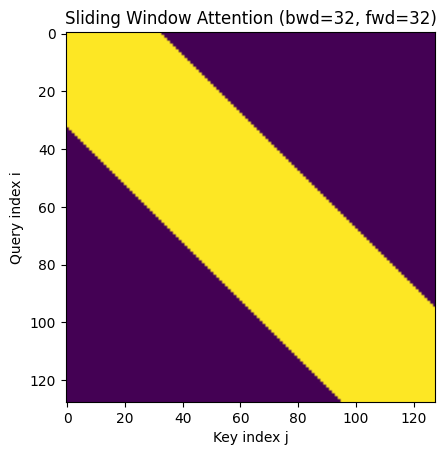

In [7]:
visualize_sliding_attention(
    L=128,
    bwd_win=32,
    fwd_win=32
)

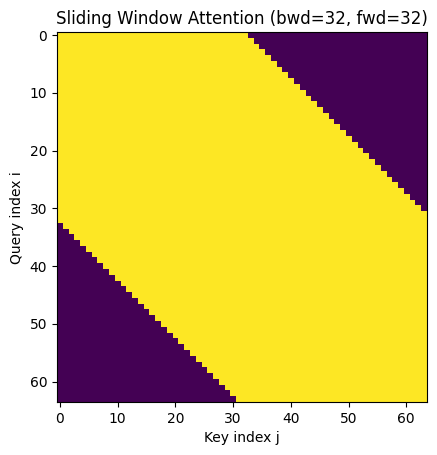

In [8]:
visualize_sliding_attention(
    L=64,
    bwd_win=32,
    fwd_win=32
)

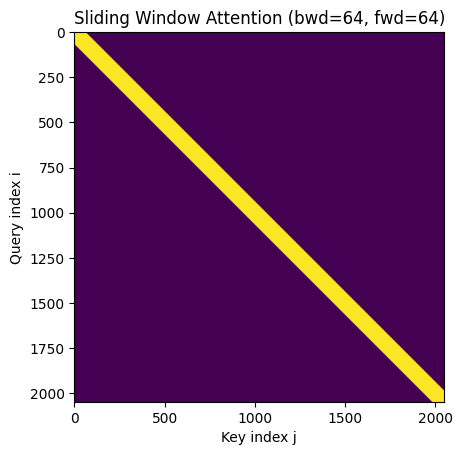

In [9]:
visualize_sliding_attention(
    L=2048,
    bwd_win=64,
    fwd_win=64
)